# PHANOTATE-rs ORF score model playground

This notebook trains and benchmarks candidate ORF scoring models for
`phanotate-rs --model`. The goal is to replace (or improve on) the default
PHANOTATE heuristic edge weight with a learned score.

## Cross-validation workflow

Because ORFs from the same genome are highly correlated, we split by
**genome** (not by individual ORF):

1. Load annotated GenBank files.
2. Extract per-ORF features with `phanotate-rs --export-features`.
3. Label each ORF by overlap with the GenBank `CDS` coordinates.
4. For each CV fold:
   - Train a model on the training genomes.
   - Export an ONNX model compatible with `--model`.
   - Run `phanotate-rs --model <onnx>` on each validation genome.
   - Compare predicted genes to GenBank annotations.
5. Pick the best model and re-train on all data.

Any classifier that can be exported to ONNX can be used at runtime; the
notebook uses logistic regression as the default example.


In [1]:
import json
import re
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Allow importing the training-script helpers
sys.path.insert(0, "..")
from scripts.train_orf_score_model import (
    export_linear_to_onnx,
    parse_genbank,
    _majority_table,
    SUPPORTED_TABLES,
    FEATURE_NAMES,
    NUM_FEATURES,
)

def _find_phanotate_binary() -> str:
    """Locate the phanotate-rs binary, preferring release builds."""
    candidates = [
        "../target/release/phanotate-rs",
        "../target/debug/phanotate-rs",
        "phanotate-rs",
    ]
    for cand in candidates:
        found = shutil.which(cand)
        if found:
            return found
    raise RuntimeError(
        "Could not find phanotate-rs binary. Build it with `cargo build --release`."
    )

BINARY = _find_phanotate_binary()
print("Using binary:", BINARY)

# Path to annotated GenBank files
GENBANK_DIR = Path("../tests/golden/annotgenomes")
if not GENBANK_DIR.exists():
    raise FileNotFoundError(f"Directory not found: {GENBANK_DIR}")

gb_paths = sorted(GENBANK_DIR.rglob("*.gb"))
print(f"Found {len(gb_paths)} GenBank files")


Using binary: ../target/release/phanotate-rs
Found 4467 GenBank files


## 1. Extract features and labels for every genome

We call `phanotate-rs --export-features` for each GenBank file. The first
two columns of the TSV are `start`/`stop`; the remaining columns are the
`OrfFeatures` vector. Labels are derived from GenBank `CDS` features.

In [2]:
def load_genome_features(path: Path, table_override: int | None = None) -> pd.DataFrame:
    '''Return a DataFrame of ORF features + labels for one GenBank file.'''
    _, entries = parse_genbank(str(path))

    if table_override is not None:
        table = table_override
    else:
        table = _majority_table(entries)
        if table not in SUPPORTED_TABLES:
            raise ValueError(f"Unsupported table {table} in {path}")

    # Build label set from CDS coordinates (must match PHANOTATE SCO start/stop)
    labels = set()
    for s, e, strand, _ in entries:
        if e - s + 1 < 3:
            continue
        if strand == "+":
            labels.add((s, e))
        else:
            labels.add((e, s))

    with tempfile.NamedTemporaryFile(mode="w", suffix=".tsv", delete=False) as tmp:
        features_path = tmp.name

    try:
        subprocess.run(
            [BINARY, "-i", str(path), "-g", str(table), "--export-features", features_path],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
        df = pd.read_csv(features_path, sep="\t")
    finally:
        Path(features_path).unlink(missing_ok=True)

    df["genome"] = path.stem
    df["table"] = table
    df["is_gene"] = df.apply(lambda r: 1 if (int(r["start"]), int(r["stop"])) in labels else 0, axis=1)
    return df


records = []
skipped = []
for p in tqdm(gb_paths[:50]):
    try:
        records.append(load_genome_features(p))
    except Exception as exc:
        skipped.append((p.name, str(exc)))

if skipped:
    print("Skipped files:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

df = pd.concat(records, ignore_index=True)
print(f"Total ORFs: {len(df)}; genes: {df['is_gene'].sum()}; genomes: {df['genome'].nunique()}")
df.head()

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:01<00:59,  1.21s/it]

  6%|▌         | 3/50 [00:01<00:18,  2.58it/s]

  8%|▊         | 4/50 [00:01<00:14,  3.19it/s]

 10%|█         | 5/50 [00:01<00:11,  4.07it/s]

...

 94%|█████████▍| 47/50 [00:05<00:00, 11.33it/s]

 98%|█████████▊| 49/50 [00:05<00:00, 10.46it/s]

100%|██████████| 50/50 [00:05<00:00,  8.91it/s]

Total ORFs: 61380; genes: 1643; genomes: 50


,start,stop,log_length,rbs_bin,log_hold,pstop,sd_rbs_score,start_codon_atg,start_codon_gtg,start_codon_ttg,gc_content,frame_fwd,frame_1,frame_2,frame_3,non_sd_rbs_score,dicodon_log_likelihood,genome,table,is_gene
0,154,65,4.477337,0.0,-0.083428,0.066831,0.968778,1.0,0.0,0.0,0.355556,0.0,0.0,1.0,0.0,1.0,-0.414965,NC_000866,11,0
1,169,65,4.634729,0.0,-0.122105,0.072925,0.968778,1.0,0.0,0.0,0.323810,0.0,0.0,1.0,0.0,1.0,-0.372175,NC_000866,11,0
2,172,65,4.663439,2.0,-0.128123,0.072850,0.952220,0.0,0.0,1.0,0.324074,0.0,0.0,1.0,0.0,1.0,-0.381650,NC_000866,11,0
3,112,201,4.477337,13.0,-0.570772,0.077181,1.051510,0.0,0.0,1.0,0.288889,1.0,1.0,0.0,0.0,1.0,-0.002261,NC_000866,11,0
4,85,201,4.744932,2.0,-0.649676,0.079772,0.952220,1.0,0.0,0.0,0.307692,1.0,1.0,0.0,0.0,1.0,-0.196700,NC_000866,11,0


In [3]:
df

,start,stop,log_length,rbs_bin,log_hold,pstop,sd_rbs_score,start_codon_atg,start_codon_gtg,start_codon_ttg,gc_content,frame_fwd,frame_1,frame_2,frame_3,non_sd_rbs_score,dicodon_log_likelihood,genome,table,is_gene
0,154,65,4.477337,0.0,-0.083428,0.066831,0.968778,1.0,0.0,0.0,0.355556,0.0,0.0,1.0,0.0,1.0,-0.414965,NC_000866,11,0
1,169,65,4.634729,0.0,-0.122105,0.072925,0.968778,1.0,0.0,0.0,0.323810,0.0,0.0,1.0,0.0,1.0,-0.372175,NC_000866,11,0
2,172,65,4.663439,2.0,-0.128123,0.072850,0.952220,0.0,0.0,1.0,0.324074,0.0,0.0,1.0,0.0,1.0,-0.381650,NC_000866,11,0
3,112,201,4.477337,13.0,-0.570772,0.077181,1.051510,0.0,0.0,1.0,0.288889,1.0,1.0,0.0,0.0,1.0,-0.002261,NC_000866,11,0
4,85,201,4.744932,2.0,-0.649676,0.079772,0.952220,1.0,0.0,0.0,0.307692,1.0,1.0,0.0,0.0,1.0,-0.196700,NC_000866,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61375,38085,38204,4.770685,0.0,-1.242596,0.061250,0.948276,1.0,0.0,0.0,0.350000,1.0,0.0,0.0,1.0,1.0,-0.196266,NC_002730,11,0
61376,38061,38204,4.955827,0.0,-1.566176,0.066782,0.948276,1.0,0.0,0.0,0.326389,1.0,0.0,0.0,1.0,1.0,-0.180611,NC_002730,11,0
61377,38238,38116,4.795791,0.0,-0.932500,0.080014,0.948276,0.0,0.0,1.0,0.325203,0.0,1.0,0.0,0.0,1.0,-0.240329,NC_002730,11,0
61378,38288,38178,4.691348,0.0,-1.838392,0.060707,0.948276,0.0,1.0,0.0,0.387387,0.0,0.0,0.0,1.0,1.0,-0.087338,NC_002730,11,0


## 2. Quick EDA

Look at feature distributions and how they differ between genes and
non-genes.

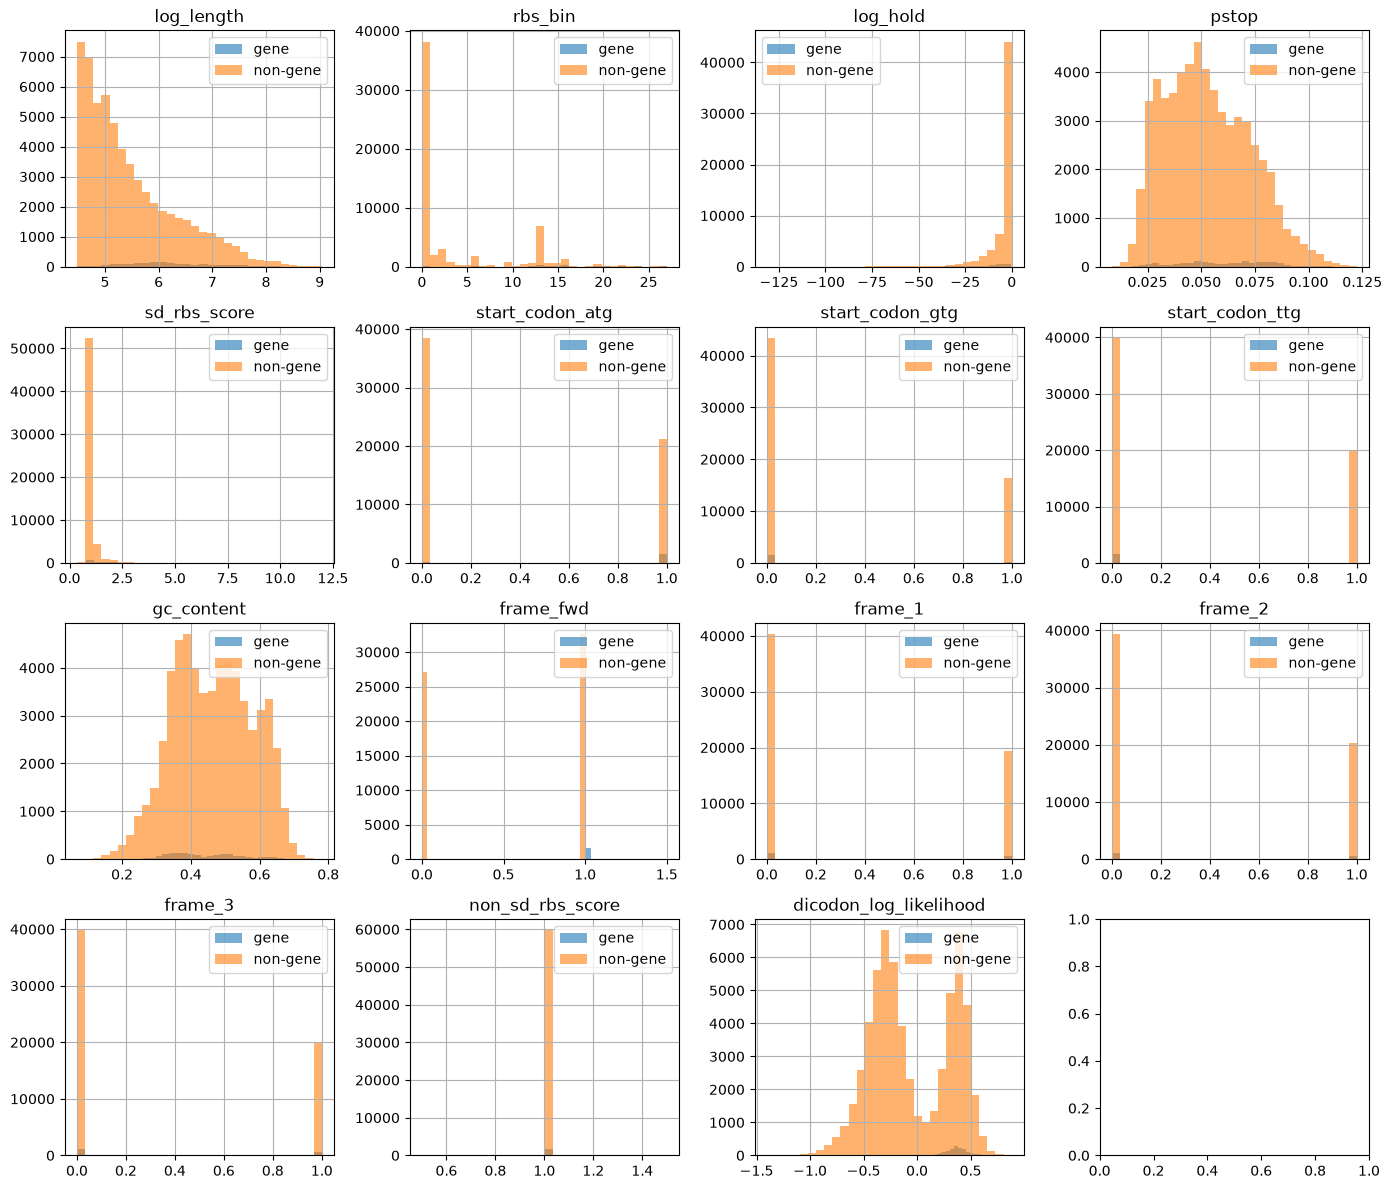

In [4]:
Path("outputs").mkdir(exist_ok=True)

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i]
    df[df["is_gene"] == 1][col].hist(ax=ax, bins=30, alpha=0.6, label="gene")
    df[df["is_gene"] == 0][col].hist(ax=ax, bins=30, alpha=0.6, label="non-gene")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig("outputs/feature_distributions.png", dpi=150)
plt.show()

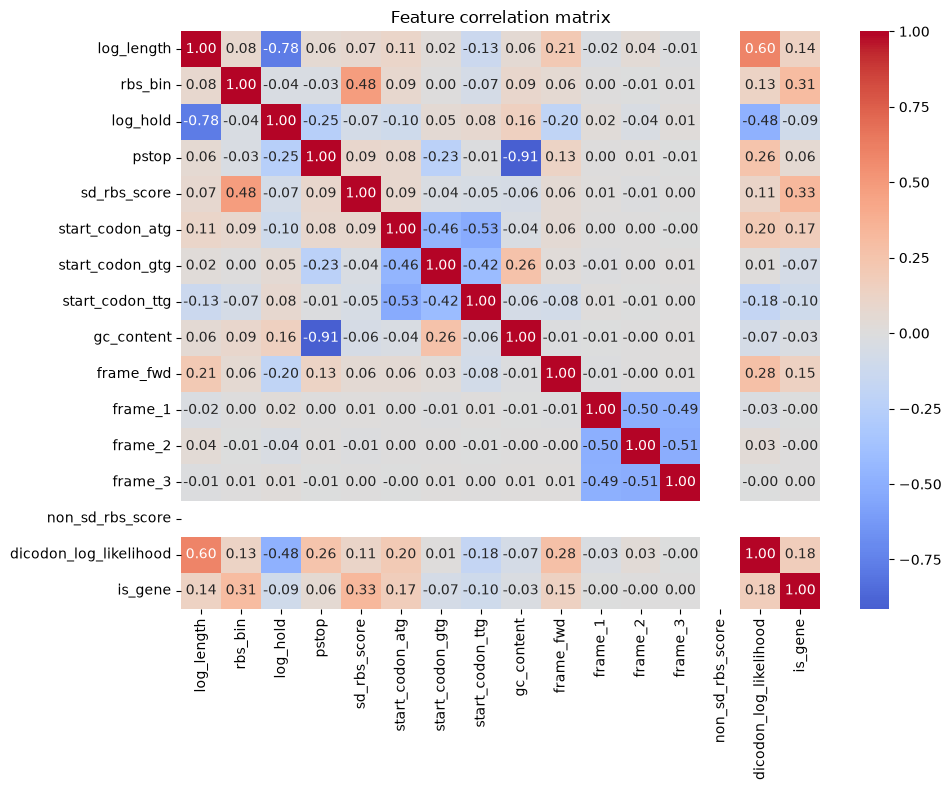

In [5]:
corr = df[FEATURE_NAMES + ["is_gene"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("outputs/feature_correlations.png", dpi=150)
plt.show()

## 3. Genome-stratified cross-validation

We split by `genome`. For each fold we:

- standardise features on the training ORFs,
- fit one or more candidate models,
- export the best model to ONNX,
- run `phanotate-rs --model` on each validation genome,
- compare predicted gene coordinates to the GenBank CDS set.

The helper below converts a fitted linear model into the ONNX format
consumed by `src/onnx_scorer.rs`.


In [6]:
def genome_cds_set(path: Path) -> set:
    """Return the set of true gene coordinates from a GenBank file.

    Coordinates are normalised to match PHANOTATE's SCO output:
    (start_codon_start, stop_codon_end). For forward genes this is (s, e);
    for reverse genes it is (e, s).
    """
    _, entries = parse_genbank(str(path))
    coords = set()
    for s, e, strand, _ in entries:
        if strand == "+":
            coords.add((s, e))
        else:
            coords.add((e, s))
    return coords


def predict_genes(path: Path, model_path: Path, table: int) -> set:
    """Run phanotate-rs and return the set of predicted (start, stop) genes."""
    cmd = [BINARY, "-i", str(path), "-g", str(table), "-f", "sco"]
    if model_path.exists() and str(model_path) != "/dev/null":
        cmd.extend(["--model", str(model_path)])
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("	")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            # Normalise to (low, high) regardless of strand.
            preds.add((min(start, stop), max(start, stop)))
    return preds


def gene_metrics(pred: set, true: set) -> dict:
    """Compute exact-match precision, recall and F1 for predicted genes."""
    tp = len(pred & true)
    fp = len(pred - true)
    fn = len(true - pred)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0.0
    )
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}


In [7]:
genome_ids = df["genome"].unique()
n_folds = min(3, len(genome_ids))
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

fold_results = []
fold_idx = 1
for train_idx, val_idx in kf.split(genome_ids):
    train_genomes = genome_ids[train_idx]
    val_genomes = genome_ids[val_idx]

    train_df = df[df["genome"].isin(train_genomes)]
    val_df = df[df["genome"].isin(val_genomes)]

    X_train = train_df[FEATURE_NAMES].values
    y_train = train_df["is_gene"].values
    X_val = val_df[FEATURE_NAMES].values
    y_val = val_df["is_gene"].values

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0.0] = 1.0

    # Candidate 1: logistic regression (exportable)
    lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")
    lr.fit((X_train - mean) / std, y_train)
    val_prob_lr = lr.predict_proba((X_val - mean) / std)[:, 1]

    # Candidate 2: XGBoost (exportable via ONNX)
    xgb_fold = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    )
    xgb_fold.fit(X_train, y_train)
    val_prob_xgb = xgb_fold.predict_proba(X_val)[:, 1]

    # ORF-level classification metrics
    orf_metrics = {
        "fold": fold_idx,
        "n_train_genomes": len(train_genomes),
        "n_val_genomes": len(val_genomes),
        "lr_auc": roc_auc_score(y_val, val_prob_lr),
        "xgb_auc": roc_auc_score(y_val, val_prob_xgb),
    }

    # Export the logistic-regression model and run the full PHANOTATE pipeline
    model_path = Path(f"outputs/model_fold{fold_idx}.onnx")
    export_linear_to_onnx(lr, mean, std, model_path)

    pipeline_metrics = []
    for p in gb_paths:
        if p.stem not in val_genomes:
            continue
        table = int(df[df["genome"] == p.stem]["table"].iloc[0])
        pred = predict_genes(p, model_path, table)
        true = genome_cds_set(p)
        m = gene_metrics(pred, true)
        m["genome"] = p.stem
        pipeline_metrics.append(m)

    if pipeline_metrics:
        pm = pd.DataFrame(pipeline_metrics)
        orf_metrics["pipeline_precision"] = pm["precision"].mean()
        orf_metrics["pipeline_recall"] = pm["recall"].mean()
        orf_metrics["pipeline_f1"] = pm["f1"].mean()

    fold_results.append(orf_metrics)
    print(f"Fold {fold_idx}: {orf_metrics}")
    fold_idx += 1

pd.DataFrame(fold_results)


Fold 1: {'fold': 1, 'n_train_genomes': 33, 'n_val_genomes': 17, 'lr_auc': 0.9697186671528526, 'xgb_auc': 0.9699998524256002, 'pipeline_precision': np.float64(0.5831773400620928), 'pipeline_recall': np.float64(0.7482639543407461), 'pipeline_f1': np.float64(0.6456318822252936)}


Fold 2: {'fold': 2, 'n_train_genomes': 33, 'n_val_genomes': 17, 'lr_auc': 0.9724007707472593, 'xgb_auc': 0.9740005392853801, 'pipeline_precision': np.float64(0.6066361980872529), 'pipeline_recall': np.float64(0.7114870295698194), 'pipeline_f1': np.float64(0.6523210739495443)}


Fold 3: {'fold': 3, 'n_train_genomes': 34, 'n_val_genomes': 16, 'lr_auc': 0.9663024330870584, 'xgb_auc': 0.9685343977979006, 'pipeline_precision': np.float64(0.5891268351996424), 'pipeline_recall': np.float64(0.761869553569078), 'pipeline_f1': np.float64(0.6560539849599603)}


,fold,n_train_genomes,n_val_genomes,lr_auc,xgb_auc,pipeline_precision,pipeline_recall,pipeline_f1
0,1,33,17,0.969719,0.970000,0.583177,0.748264,0.645632
1,2,33,17,0.972401,0.974001,0.606636,0.711487,0.652321
2,3,34,16,0.966302,0.968534,0.589127,0.761870,0.656054


## 4. Compare candidate models

Plot ORF-level ROC and PR curves on held-out genomes. The exportable model
is logistic regression; XGBoost is shown for comparison.

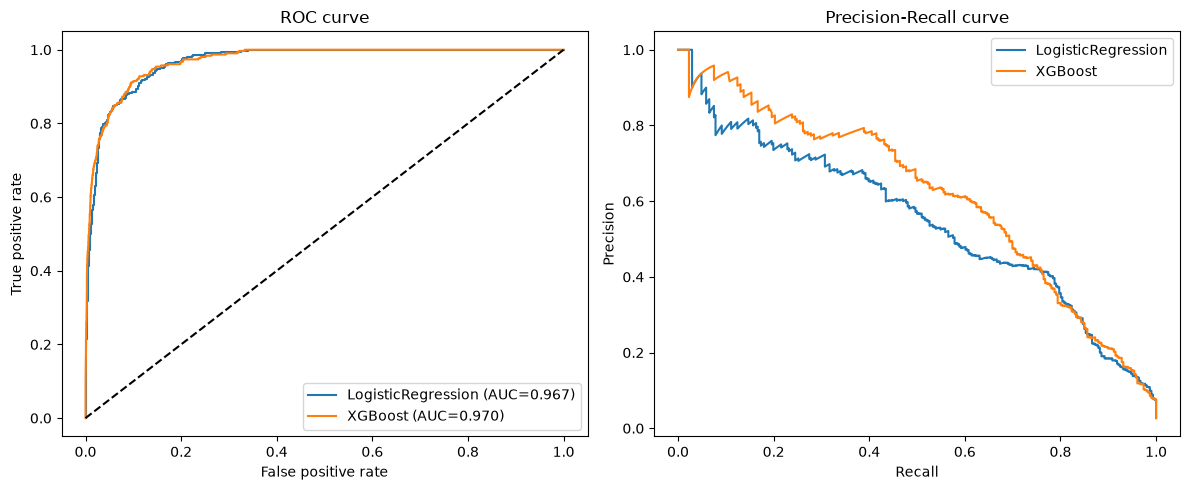

In [8]:
# Simple held-out split for model comparison plots
np.random.seed(42)
val_genomes_plot = np.random.choice(genome_ids, size=max(1, len(genome_ids) // 5), replace=False)
train_genomes_plot = [g for g in genome_ids if g not in val_genomes_plot]

train_df_p = df[df["genome"].isin(train_genomes_plot)]
val_df_p = df[df["genome"].isin(val_genomes_plot)]
X_train_p = train_df_p[FEATURE_NAMES].values
y_train_p = train_df_p["is_gene"].values
X_val_p = val_df_p[FEATURE_NAMES].values
y_val_p = val_df_p["is_gene"].values

mean_p = X_train_p.mean(axis=0)
std_p = X_train_p.std(axis=0)
std_p[std_p == 0.0] = 1.0

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs"),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(len(y_train_p) - y_train_p.sum()) / y_train_p.sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    ),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for name, m in models.items():
    if name == "LogisticRegression":
        m.fit((X_train_p - mean_p) / std_p, y_train_p)
        prob = m.predict_proba((X_val_p - mean_p) / std_p)[:, 1]
    else:
        m.fit(X_train_p, y_train_p)
        prob = m.predict_proba(X_val_p)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_p, prob)
    prec, rec, _ = precision_recall_curve(y_val_p, prob)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val_p, prob):.3f})")
    ax2.plot(rec, prec, label=f"{name}")

ax1.plot([0, 1], [0, 1], "k--")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve")
ax1.legend()

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve")
ax2.legend()

plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()

## 5. Train final model and export

Retrain the chosen model on all genomes and export it to ONNX.
Both logistic-regression and non-linear classifiers (e.g. XGBoost) can
be exported to ONNX and used directly with `phanotate-rs --model`.


In [9]:
X_all = df[FEATURE_NAMES].values
y_all = df["is_gene"].values

mean_all = X_all.mean(axis=0)
std_all = X_all.std(axis=0)
std_all[std_all == 0.0] = 1.0

final_model = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")
final_model.fit((X_all - mean_all) / std_all, y_all)

onnx_path = Path("outputs/model_final.onnx")
export_linear_to_onnx(final_model, mean_all, std_all, onnx_path)
print(f"Exported ONNX model to {onnx_path}")

# Show feature importance (coefficients)
coef_df = pd.DataFrame({"feature": FEATURE_NAMES, "coeff": final_model.coef_.ravel()})
coef_df = coef_df.sort_values("coeff", key=abs, ascending=False)
print(coef_df)

Exported ONNX model to outputs/model_final.onnx
                   feature     coeff
9                frame_fwd  4.786635
5          start_codon_atg  2.883143
6          start_codon_gtg  1.852309
7          start_codon_ttg  1.578489
14  dicodon_log_likelihood  1.255915
1                  rbs_bin  1.158391
0               log_length  0.779941
2                 log_hold  0.566449
3                    pstop  0.456834
4             sd_rbs_score  0.102630
8               gc_content  0.057922
12                 frame_3  0.051742
10                 frame_1 -0.041994
11                 frame_2 -0.010005
13        non_sd_rbs_score  0.000000


## 5b. Validate the ONNX model end-to-end


In [10]:
# Quick sanity check: compare ONNX predictions to annotations for one genome
example_genome = gb_paths[0]
example_table = int(df[df["genome"] == example_genome.stem]["table"].iloc[0])
true_set = genome_cds_set(example_genome)
model_pred_onnx = predict_genes(example_genome, onnx_path, example_table)
print("ONNX model:", gene_metrics(model_pred_onnx, true_set))


ONNX model: {'precision': 0.7931034482758621, 'recall': 0.8273381294964028, 'f1': 0.8098591549295774, 'tp': 230, 'fp': 60, 'fn': 48}


## 6. Validate the final model on a held-out genome

Pick a genome not seen during final training (or the same CV validation set)
and compare `--model` predictions to the GenBank annotations.

In [11]:
# Example: validate on the first validation-genome from the last CV fold
example_genome = gb_paths[0]
example_table = int(df[df["genome"] == example_genome.stem]["table"].iloc[0])

default_pred = predict_genes(example_genome, Path("/dev/null"), example_table)
model_pred = predict_genes(example_genome, onnx_path, example_table)
true_set = genome_cds_set(example_genome)

print("Default PHANOTATE:", gene_metrics(default_pred, true_set))
print("Learned model:", gene_metrics(model_pred, true_set))


Default PHANOTATE: {'precision': 0.8215488215488216, 'recall': 0.8776978417266187, 'f1': 0.848695652173913, 'tp': 244, 'fp': 53, 'fn': 34}
Learned model: {'precision': 0.7931034482758621, 'recall': 0.8273381294964028, 'f1': 0.8098591549295774, 'tp': 230, 'fp': 60, 'fn': 48}


## 7. Train an XGBoost model and compare

XGBoost can capture non-linear relationships between features (e.g. interactions between RBS signals, start codon and dicodon score). We train one on the same data, export it to ONNX, and compare the end-to-end gene predictions against the logistic-regression and default PHANOTATE models.


In [12]:
def export_xgboost_to_onnx(model, path: Path, n_features: int = NUM_FEATURES) -> None:
    """Export an XGBoost classifier to ONNX."""
    from onnxmltools.convert.common.data_types import FloatTensorType
    import onnxmltools

    onnx_model = onnxmltools.convert_xgboost(
        model, initial_types=[("input", FloatTensorType([None, n_features]))]
    )
    path.write_bytes(onnx_model.SerializeToString())


In [13]:
from xgboost import XGBClassifier

# Train an XGBoost classifier on all genomes (raw, unstandardised features)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(y_all) - y_all.sum()) / y_all.sum(),
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
)
xgb.fit(X_all, y_all)

xgb_path = Path("outputs/model_xgb.onnx")
export_xgboost_to_onnx(xgb, xgb_path)
print(f"Exported XGBoost model to {xgb_path}")

# Feature importances
importance_df = pd.DataFrame({"feature": FEATURE_NAMES, "importance": xgb.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df)


Exported XGBoost model to outputs/model_xgb.onnx
                   feature  importance
9                frame_fwd    0.345311
1                  rbs_bin    0.199186
14  dicodon_log_likelihood    0.181894
5          start_codon_atg    0.086386
6          start_codon_gtg    0.026426
7          start_codon_ttg    0.023047
8               gc_content    0.022854
0               log_length    0.019077
4             sd_rbs_score    0.018911
3                    pstop    0.017337
12                 frame_3    0.016695
10                 frame_1    0.016539
2                 log_hold    0.015109
11                 frame_2    0.011228
13        non_sd_rbs_score    0.000000


In [14]:
# Compare default, logistic-regression and XGBoost predictions on one genome
example_genome = gb_paths[0]
example_table = int(df[df["genome"] == example_genome.stem]["table"].iloc[0])
true_set = genome_cds_set(example_genome)

default_pred = predict_genes(example_genome, Path("/dev/null"), example_table)
lr_pred = predict_genes(example_genome, onnx_path, example_table)
xgb_pred = predict_genes(example_genome, xgb_path, example_table)

print("Default PHANOTATE:", gene_metrics(default_pred, true_set))
print("Logistic regression:", gene_metrics(lr_pred, true_set))
print("XGBoost:          ", gene_metrics(xgb_pred, true_set))


Default PHANOTATE: {'precision': 0.8215488215488216, 'recall': 0.8776978417266187, 'f1': 0.848695652173913, 'tp': 244, 'fp': 53, 'fn': 34}
Logistic regression: {'precision': 0.7931034482758621, 'recall': 0.8273381294964028, 'f1': 0.8098591549295774, 'tp': 230, 'fp': 60, 'fn': 48}
XGBoost:           {'precision': 0.7552447552447552, 'recall': 0.7769784172661871, 'f1': 0.7659574468085106, 'tp': 216, 'fp': 70, 'fn': 62}


## 8. Benchmark against PHANOTATE-rs 0.1.2 and prodigal-gv

Add two additional baselines:

- **PHANOTATE-rs 0.1.2**: the previous Rust release, built from the `v0.1.2` git tag and placed at `tools/phanotate-rs-0.1.2`.
- **prodigal-gv**: the viral-aware prodigal fork, run through the `pyrodigal-gv` Python bindings.


In [15]:
from pathlib import Path
import subprocess
import pyrodigal_gv

PHANOTATE_RS_012 = Path("tools/phanotate-rs-0.1.2").resolve()

def predict_genes_phanotate_rs_012(path: Path, table: int) -> set:
    """Run PHANOTATE-rs v0.1.2 and return predicted (start, stop) genes."""
    if not PHANOTATE_RS_012.exists():
        raise FileNotFoundError(
            f"PHANOTATE-rs 0.1.2 binary not found at {PHANOTATE_RS_012}. "
            "Build it from the v0.1.2 tag: git worktree add /tmp/phanotate-rs-0.1.2-src v0.1.2 && cargo build --release"
        )
    cmd = [str(PHANOTATE_RS_012), "-i", str(path), "-g", str(table), "-f", "sco"]
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            # Normalise to (low, high) regardless of strand.
            preds.add((min(start, stop), max(start, stop)))
    return preds

def predict_genes_prodigal_gv(path: Path, table: int | None = None) -> set:
    """Run prodigal-gv via pyrodigal-gv and return predicted (start, stop) genes."""
    seq, _ = parse_genbank(str(path))
    finder = pyrodigal_gv.ViralGeneFinder(meta=True)
    genes = finder.find_genes(seq)
    preds = set()
    for g in genes:
        # pyrodigal coordinates are 1-based inclusive. For reverse-strand genes
        # begin is the leftmost base (stop-codon end) and end is the rightmost
        # base (start-codon start), matching PHANOTATE's SCO convention.
        preds.add((g.begin, g.end))
    return preds


In [16]:
# Original Python PHANOTATE (requires the sibling ../PHANOTATE repo and a Python env with its deps)
PHANOTATE_PY = Path.cwd().parent.parent / "PHANOTATE" / "phanotate.py"
PHANOTATE_PY_PYTHON = Path("/Users/javis/miniconda3/envs/phanotate_rs/bin/python")

def predict_genes_phanotate_py(path: Path, table: int | None = None) -> set:
    """Run the original Python PHANOTATE and return predicted (start, stop) genes."""
    if not PHANOTATE_PY.exists():
        raise FileNotFoundError(
            f"Original PHANOTATE not found at {PHANOTATE_PY}. "
            "Clone it next to this repo: git clone https://github.com/deprekate/PHANOTATE.git ../PHANOTATE"
        )
    seq, _ = parse_genbank(str(path))
    with tempfile.NamedTemporaryFile(mode="w", suffix=".fna", delete=False) as tmp:
        tmp.write(f">{path.stem}\n{seq}\n")
        fasta = tmp.name
    try:
        result = subprocess.run(
            [str(PHANOTATE_PY_PYTHON), str(PHANOTATE_PY), "-f", "tabular", fasta],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
    finally:
        Path(fasta).unlink(missing_ok=True)

    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 3:
            start, stop = int(cols[0]), int(cols[1])
            # Original PHANOTATE outputs forward (start<stop) and reverse (start>stop).
            # Normalise to the same SCO convention used by phanotate-rs: (low, high).
            preds.add((min(start, stop), max(start, stop)))
    return preds


In [17]:
# Conda-installed PHANOTATE-rs binary (may differ from the local dev build)
PHANOTATE_RS_CONDA = Path("/Users/javis/miniconda3/envs/phanotate_rs/bin/phanotate-rs")

def predict_genes_phanotate_rs_conda(path: Path, table: int) -> set:
    """Run the conda-installed phanotate-rs binary and return predicted gene coordinates."""
    if not PHANOTATE_RS_CONDA.exists():
        raise FileNotFoundError(f"Conda phanotate-rs binary not found at {PHANOTATE_RS_CONDA}")
    cmd = [str(PHANOTATE_RS_CONDA), "-i", str(path), "-g", str(table), "-f", "sco"]
    result = subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    preds = set()
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) >= 2:
            start, stop = int(cols[0]), int(cols[1])
            # Normalise to (low, high) regardless of strand.
            preds.add((min(start, stop), max(start, stop)))
    return preds


In [18]:
# Compare all predictors on the example genome
example_genome = gb_paths[0]
example_table = int(df[df["genome"] == example_genome.stem]["table"].iloc[0])
true_set = genome_cds_set(example_genome)

default_pred = predict_genes(example_genome, Path("/dev/null"), example_table)
lr_pred = predict_genes(example_genome, onnx_path, example_table)
xgb_pred = predict_genes(example_genome, xgb_path, example_table)
py_pred = predict_genes_phanotate_py(example_genome, example_table)
old_pred = predict_genes_phanotate_rs_012(example_genome, example_table)
conda_pred = predict_genes_phanotate_rs_conda(example_genome, example_table)
pgv_pred = predict_genes_prodigal_gv(example_genome, example_table)

print("Default PHANOTATE-rs 0.1.3:", gene_metrics(default_pred, true_set))
print("Logistic regression:     ", gene_metrics(lr_pred, true_set))
print("XGBoost:                ", gene_metrics(xgb_pred, true_set))
print("PHANOTATE-rs 0.1.2:    ", gene_metrics(old_pred, true_set))
print("prodigal-gv:            ", gene_metrics(pgv_pred, true_set))
print("PHANOTATE-rs (conda):   ", gene_metrics(conda_pred, true_set))
print("PHANOTATE.py:           ", gene_metrics(py_pred, true_set))


Default PHANOTATE-rs 0.1.3: {'precision': 0.8215488215488216, 'recall': 0.8776978417266187, 'f1': 0.848695652173913, 'tp': 244, 'fp': 53, 'fn': 34}
Logistic regression:      {'precision': 0.7931034482758621, 'recall': 0.8273381294964028, 'f1': 0.8098591549295774, 'tp': 230, 'fp': 60, 'fn': 48}
XGBoost:                 {'precision': 0.7552447552447552, 'recall': 0.7769784172661871, 'f1': 0.7659574468085106, 'tp': 216, 'fp': 70, 'fn': 62}
PHANOTATE-rs 0.1.2:     {'precision': 0.8215488215488216, 'recall': 0.8776978417266187, 'f1': 0.848695652173913, 'tp': 244, 'fp': 53, 'fn': 34}
prodigal-gv:             {'precision': 0.909433962264151, 'recall': 0.8669064748201439, 'f1': 0.8876611418047884, 'tp': 241, 'fp': 24, 'fn': 37}
PHANOTATE-rs (conda):    {'precision': 0.8215488215488216, 'recall': 0.8776978417266187, 'f1': 0.848695652173913, 'tp': 244, 'fp': 53, 'fn': 34}
PHANOTATE.py:            {'precision': 0.8299319727891157, 'recall': 0.8776978417266187, 'f1': 0.8531468531468531, 'tp': 244,

## 9. Small-genome benchmark: NC_001365 (SpV1, table 4 with auto-detection)

Compare predictors on the small `tests/golden/NC_001365.fa` genome, where the correct translation table is 4. PHANOTATE-rs is run with `--detect-table`; prodigal-gv is run in meta mode (its single-mode trainer refuses sequences < 20 kb).


In [19]:
NC_001365_FASTA = Path("../tests/golden/NC_001365.fa").resolve()
NC_001365_GB = Path("../tests/golden/NC_001365.gb").resolve()

nc_true = genome_cds_set(NC_001365_GB)
print(f"True CDS: {len(nc_true)}")

nc_default_detect = predict_genes(NC_001365_FASTA, Path("/dev/null"), table=4)  # same as --detect-table result
nc_lr = predict_genes(NC_001365_FASTA, onnx_path, table=4)
nc_xgb = predict_genes(NC_001365_FASTA, xgb_path, table=4)

# prodigal-gv in meta mode (table-4 training requires >= 20 kb)
nc_seq, _ = parse_genbank(str(NC_001365_GB))
gf_nc = pyrodigal_gv.ViralGeneFinder(meta=True)
nc_pgv = set((min(g.begin, g.end), max(g.begin, g.end)) for g in gf_nc.find_genes(nc_seq))

print(f"{"Predictor":<35} {"Precision":>10} {"Recall":>8} {"F1":>8} {"TP":>5} {"FP":>5} {"FN":>5}")
print("-" * 85)
for label, preds in [
    ("PHANOTATE-rs -g 4 / --detect-table", nc_default_detect),
    ("PHANOTATE-rs + LR model", nc_lr),
    ("PHANOTATE-rs + XGBoost model", nc_xgb),
    ("prodigal-gv meta", nc_pgv),
]:
    m = gene_metrics(preds, nc_true)
    p, r, f1, tp, fp, fn = m["precision"], m["recall"], m["f1"], m["tp"], m["fp"], m["fn"]
    print(f"{label:<35} {p:>10.3f} {r:>8.3f} {f1:>8.3f} {tp:>5} {fp:>5} {fn:>5}")


True CDS: 12


Predictor                            Precision   Recall       F1    TP    FP    FN
-------------------------------------------------------------------------------------
PHANOTATE-rs -g 4 / --detect-table       0.211    0.333    0.258     4    15     8
PHANOTATE-rs + LR model                  0.474    0.750    0.581     9    10     3
PHANOTATE-rs + XGBoost model             0.526    0.833    0.645    10     9     2
prodigal-gv meta                         0.769    0.833    0.800    10     3     2


## Next steps

- Try different feature sets or add engineered features in `src/ml_features.rs`.
- Experiment with class weights, regularisation, or alternative models.
- For non-linear models (XGBoost), export to ONNX with `onnxmltools`.
- Use the exported ONNX model with PHANOTATE-rs:
  ```bash
  ./target/release/phanotate-rs -i genome.fasta --model outputs/model_final.onnx -f sco
  ```